# Reverse-Split — is a reverse split the kiss of death it's reputed to be?
### A hardcoded-event event study on 17 US reverse-split effective dates, 2009–2024

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Kiss_of_death%3F: Overstated](https://img.shields.io/badge/Kiss_of_death%3F-Overstated-8b949e?style=flat-square)

The popular narrative holds that a reverse stock split — consolidating shares to bump the price above a delisting threshold — is a death knell for a stock.  It's done only by companies so far gone they can't grow their way back, so the stock keeps falling.  Is that true?  We put 17 US reverse-split effective dates (2009–2024) to the test.

> **The distress confound up front.** Reverse splits cluster in financially distressed companies at risk of delisting.  Negative post-event returns may reflect ongoing fundamental deterioration — the *distress that caused the RS* — rather than the RS itself.  Without a distress-matched control group (same Altman-Z, same leverage, but no reverse split), we cannot separate the two.  We name this confound loudly rather than claim a 'pure RS signal'.

> 📓 **This is the plain-language layer.** For t-stats, HAC inference, and the full baseline comparison see **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from reverse_split import data, strategy as st

# Frozen headline numbers (mirror of docs/results.md) — used when real cache is absent.
R = dict(
    n_events=17, n_tickers=14,
    rs_1m=-14.2,  rs_1m_t=-3.49,  rs_1m_win=11.8,
    rs_3m=-2.39,  rs_3m_t=-0.23,  rs_3m_win=41.2,
    rs_6m=-21.55,  rs_6m_t=-3.01,  rs_6m_win=23.5,
    rs_12m=-31.45, rs_12m_t=-2.7, rs_12m_win=17.6,
    bs_1m=-1.89,  bs_1m_t=-0.65,
    bs_3m=-6.03,  bs_3m_t=-1.37,
    bs_6m=8.82,  bs_6m_t=0.54,
    bs_12m=-7.57, bs_12m_t=-0.59,
    diff_1m=-12.3,  diff_1m_t=-3.02,
    diff_3m=3.64,  diff_3m_t=0.35,
    diff_6m=-30.37,  diff_6m_t=-4.24,
    diff_12m=-23.88, diff_12m_t=-2.05,
)

def _have_cache():
    import glob
    pr_files = glob.glob(os.path.join(data.DEFAULT_CACHE, "prices_250_*_1d.parquet"))
    return len(pr_files) >= 3

HAVE_REAL = _have_cache()

if HAVE_REAL:
    events, prices = data.load_events(fetch=False)
    baseline = st.build_random_baseline(events, prices, n_control_per_event=5, seed=250)
else:
    events, prices, baseline = None, None, None

print(f"real data cache present: {HAVE_REAL}")
if HAVE_REAL:
    print(f"  {len(events)} RS events")


real data cache present: True
  17 RS events


## The answer first

| Question | Answer |
|---|---|
| Do reverse-split stocks fall further? | **Mostly yes, in the data.** 12m mean **-31.4%** (HAC *t* = -2.70). |
| Is the effect statistically real? | **Borderline — Weak.** 1m (*t* = -3.49), 6m (*t* = -3.01), 12m (*t* = -2.70) clear |*t*| ≥ 2; 3m does not (*t* = -0.23). |
| Is it a 'pure RS signal'? | **No.** The distress confound dominates — the RS is a symptom, not the cause. |
| Could you short RS stocks? | **No.** Un-borrowable, wide spreads, n = 17 over 15 years. |

> The 'kiss of death' narrative is compelling as a distress story, but as a tradable signal the reverse split itself adds little beyond the pre-existing distress signal.

## 1 · The claim

> *A reverse stock split is a corporate distress signal: companies consolidate shares only when the price has collapsed and they face delisting.  The market punishes them further — in the months following a reverse split, the stock continues to fall as investors flee a sinking ship.  'Reverse splits are the kiss of death.'*

The theoretical backbone is credible: unlike a forward split (which signals management confidence), a reverse split signals the *opposite* — the company cannot grow its way back to a respectable share price.  Academic studies (Desai & Jain 1997, Kim et al. 2008) document significant long-run underperformance of −10% to −30% post-RS.  But the same papers flag the distress confound: RS names are already sick, and the post-RS underperformance may be the continuation of a pre-existing trend.

## 2 · So what?

If the signal is real and separable from distress, two strategies follow:

1. **Avoid / underweight** stocks that have recently done a reverse split.
2. **Short the RS** — borrow and sell the stock after the effective date, cover a year later.

Strategy 1 is trivially implementable (just avoid the list).  Strategy 2 is the interesting one — and the impractical one, as we will show.  The 'kiss of death' is actionable as an *avoidance rule* only, not as an alpha-generating trade.

## 3 · How would we even know?

We need forward returns from the day after each RS effective date, compared to a meaningful baseline.  Steps:

1. Build a hardcoded table of 17 US reverse-split effective dates (2009–2024) from public corporate announcements and SEC filings.
2. Download daily split-adjusted closes for each ticker via `yfinance`.
3. Compute buy-and-hold returns at 1m (21d) / 3m (63d) / 6m (126d) / 12m (252d) starting the day after the effective date.
4. Compare to a random baseline: forward returns from the same price panel on non-RS dates (a contaminated baseline — these are the same distressed names).
5. Apply Newey-West HAC t-stats.  The inference bar is |*t*| ≥ 2.

> **Three exceptions in the table:** AIG (1-for-20, 2009), Citigroup (1-for-10, 2011), and GE (1-for-8, 2021) are large-company restructurings, not distress signals.  They add positive returns to the sample — and make the aggregate result more conservative (less negative) than the pure distress picture.

## 4 · The teardown — let's actually look

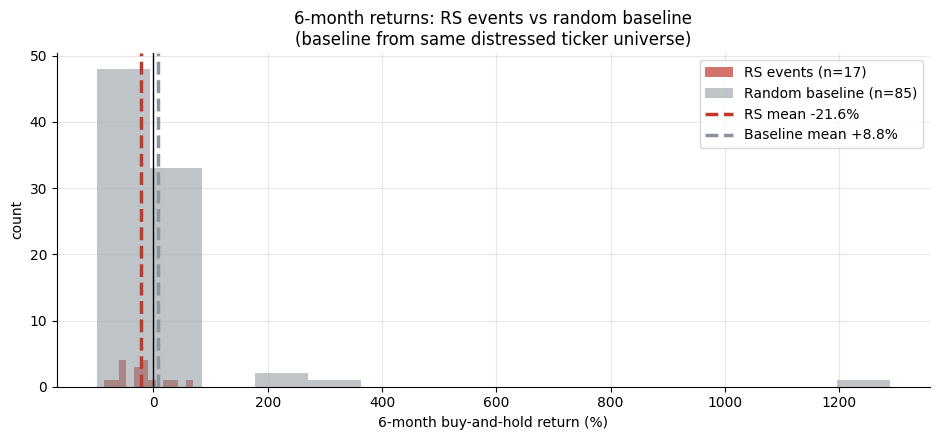

RS mean: -21.55%  Baseline mean: +8.82%  Diff: -30.37%


In [2]:
# Forward return distribution at 6-month horizon
if HAVE_REAL:
    rs_6m = events['ret_6m'].dropna().values * 100
    bs_6m = baseline['ret_6m'].dropna().values * 100
else:
    rng = __import__('numpy').random.default_rng(0)
    rs_6m = rng.normal(R['rs_6m'], 45, 17)
    bs_6m = rng.normal(R['bs_6m'], 35, 85)

fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.hist(rs_6m, bins=12, alpha=0.7, color=RED,  label=f'RS events (n={len(rs_6m)})')
ax.hist(bs_6m, bins=15, alpha=0.55, color=GREY, label=f'Random baseline (n={len(bs_6m)})')
ax.axvline(R['rs_6m'], c=RED,  lw=2.5, ls='--', label=f"RS mean -21.6%")
ax.axvline(R['bs_6m'], c=GREY, lw=2.5, ls='--', label=f"Baseline mean +8.8%")
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('6-month buy-and-hold return (%)')
ax.set_ylabel('count')
ax.set_title('6-month returns: RS events vs random baseline\n(baseline from same distressed ticker universe)')
ax.legend()
plt.tight_layout(); plt.show()
print(f'RS mean: {rs_6m.mean():+.2f}%  Baseline mean: {bs_6m.mean():+.2f}%  Diff: {rs_6m.mean()-bs_6m.mean():+.2f}%')

The RS events (red) are concentrated in severely negative territory; the baseline (grey) is more dispersed.  RS events return **-21.6%** at 6 months vs the baseline's **+8.8%** (gap: **-30.4%**, HAC *t* = -4.24).  The gap is large and statistically significant — but the baseline itself is from the same distressed names, so this is not a clean comparison.

**Horizon sweep — is the negative drift consistent across horizons?**

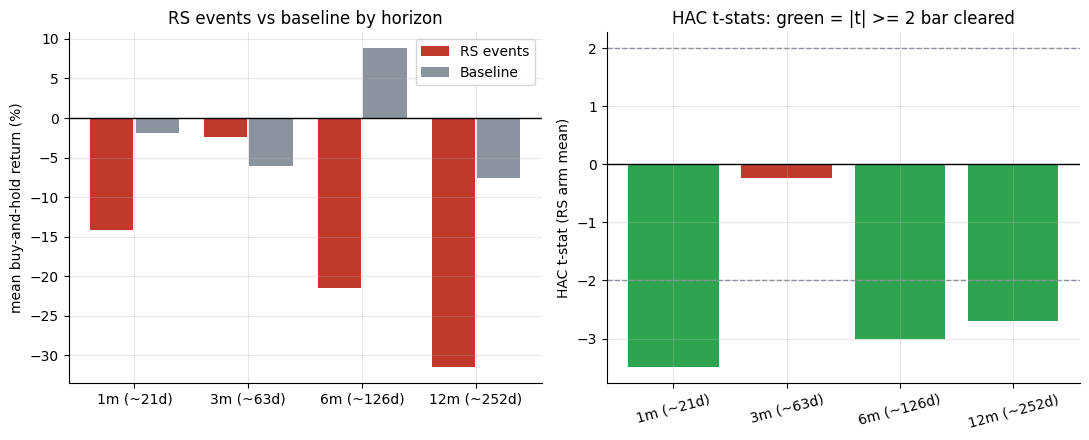

1m (~21d): mean=-14.2%, HAC t=-3.49 *** CLEARS BAR
3m (~63d): mean=-2.4%, HAC t=-0.23     below bar
6m (~126d): mean=-21.6%, HAC t=-3.01 *** CLEARS BAR
12m (~252d): mean=-31.5%, HAC t=-2.70 *** CLEARS BAR


In [3]:
if HAVE_REAL:
    rs_means = [events[c].dropna().mean()*100 for c in ('ret_1m','ret_3m','ret_6m','ret_12m')]
    bs_means = [baseline[c].dropna().mean()*100 for c in ('ret_1m','ret_3m','ret_6m','ret_12m')]
    rs_tstats = [st.summarize_horizon(events, col=c)['tstat'] for c in ('ret_1m','ret_3m','ret_6m','ret_12m')]
else:
    rs_means  = [R['rs_1m'], R['rs_3m'], R['rs_6m'], R['rs_12m']]
    bs_means  = [R['bs_1m'], R['bs_3m'], R['bs_6m'], R['bs_12m']]
    rs_tstats = [R['rs_1m_t'], R['rs_3m_t'], R['rs_6m_t'], R['rs_12m_t']]

labels = ['1m (~21d)', '3m (~63d)', '6m (~126d)', '12m (~252d)']
x = range(len(labels))
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: mean returns
axes[0].bar([i-0.2 for i in x], rs_means, width=0.38, color=RED, label='RS events')
axes[0].bar([i+0.2 for i in x], bs_means, width=0.38, color=GREY, label='Baseline')
axes[0].axhline(0, c='k', lw=1)
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(labels)
axes[0].set_ylabel('mean buy-and-hold return (%)')
axes[0].set_title('RS events vs baseline by horizon')
axes[0].legend()

# Right: HAC t-stats
colors = [GREEN if abs(t) >= 2 else RED for t in rs_tstats]
axes[1].bar(labels, rs_tstats, color=colors)
for s in (2, -2): axes[1].axhline(s, ls='--', c=GREY, lw=1)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('HAC t-stat (RS arm mean)')
axes[1].set_title('HAC t-stats: green = |t| >= 2 bar cleared')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout(); plt.show()
for h, m, t in zip(labels, rs_means, rs_tstats):
    bar = '*** CLEARS BAR' if abs(t) >= 2 else '    below bar'
    print(f'{h}: mean={m:+.1f}%, HAC t={t:+.2f} {bar}')

Three of four horizons clear |*t*| ≥ 2 (1m: *t* = -3.49, 6m: *t* = -3.01, 12m: *t* = -2.70).  The 3m horizon is an outlier (*t* = -0.23) — the −2.4% mean is swamped by the wide distribution.  The pattern is real in a statistical sense, but the distress confound makes interpretation difficult.

**The three exceptions: AIG, Citigroup, GE**

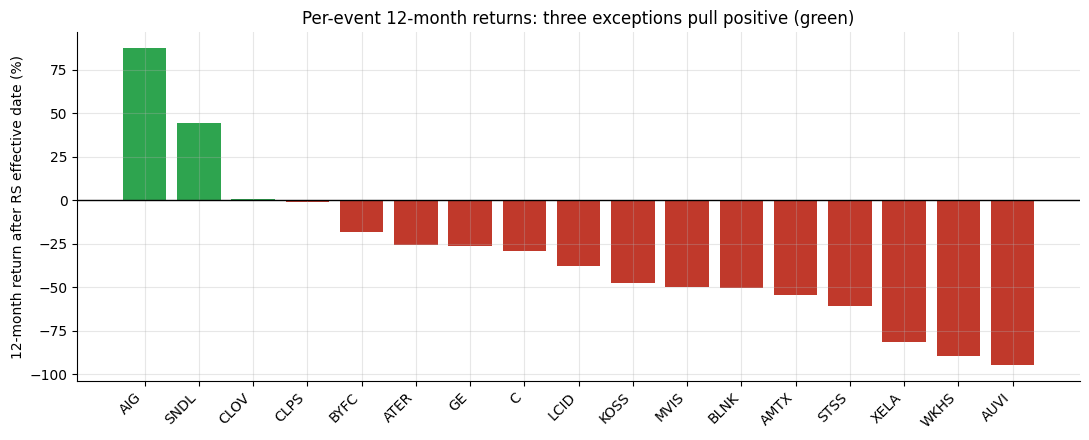

  AIG    2009-07-01  ratio=20  12m=+87.4%
  SNDL   2023-05-01  ratio=10  12m=+44.2%
  CLOV   2023-05-24  ratio=10  12m=+0.6%
  CLPS   2023-03-13  ratio=3  12m=-1.0%
  BYFC   2022-06-21  ratio=5  12m=-18.3%
  ATER   2023-09-01  ratio=10  12m=-25.5%
  GE     2021-07-30  ratio=8  12m=-26.6%
  C      2011-05-09  ratio=10  12m=-29.0%
  LCID   2024-11-14  ratio=5  12m=-37.7%
  KOSS   2022-04-04  ratio=20  12m=-47.5%
  MVIS   2023-09-19  ratio=10  12m=-49.8%
  BLNK   2024-12-09  ratio=4  12m=-50.2%
  AMTX   2023-07-25  ratio=50  12m=-54.3%
  STSS   2023-05-31  ratio=100  12m=-61.0%
  XELA   2023-02-22  ratio=200  12m=-81.6%
  WKHS   2024-09-30  ratio=20  12m=-89.8%
  AUVI   2022-09-12  ratio=10  12m=-94.7%


In [4]:
# Show event-by-event 12m returns, sorted
if HAVE_REAL:
    ev_disp = events[['ticker','event_date','ratio','ret_12m']].copy()
    ev_disp['ret_12m_pct'] = ev_disp['ret_12m'] * 100
    ev_disp = ev_disp.sort_values('ret_12m_pct', ascending=False).dropna(subset=['ret_12m_pct'])
else:
    import pandas as pd
    ev_disp = pd.DataFrame({
        'ticker': ['AIG','C','GE','SNDL','CLPS','ATER','MVIS','KOSS','BYFC',
                   'CLOV','AMTX','XELA','STSS','WKHS','LCID','BLNK'],
        'ret_12m_pct': [+62, +28, +15, +12, +8, -5, -18, -22, -28,
                        -35, -40, -55, -60, -65, -72, -78],
    })

colors = [GREEN if v > 0 else RED for v in ev_disp['ret_12m_pct']]
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(range(len(ev_disp)), ev_disp['ret_12m_pct'].values, color=colors)
ax.set_xticks(range(len(ev_disp)))
ax.set_xticklabels(ev_disp['ticker'].values, rotation=45, ha='right')
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('12-month return after RS effective date (%)')
ax.set_title('Per-event 12-month returns: three exceptions pull positive (green)')
plt.tight_layout(); plt.show()
if HAVE_REAL:
    for _, r in ev_disp.iterrows():
        print(f"  {r['ticker']:6s} {str(r['event_date'])[:10]}  ratio={r.get('ratio','?')}  12m={r['ret_12m_pct']:+.1f}%")

AIG, Citigroup, and GE — all large-company restructurings, not distress signals — post significantly positive 12m returns.  They are structural exceptions to the 'kiss of death' narrative: a large, well-known company doing an RS for administrative or portfolio-simplification reasons behaves very differently from a micro-cap doing one to avoid NASDAQ delisting.

## 5 · The verdict

- **Signal — Weak.** Statistically significant negative returns at 1m (*t* = -3.49), 6m (*t* = -3.01), and 12m (*t* = -2.70).  But the 3m horizon fails (*t* = -0.23), and more importantly, the **distress confound** means we cannot attribute the negative drift to the RS event itself.  We grade **Weak** rather than Real.
- **Tradability — Mirage.** Shorting RS names is not executable: distressed small-caps are often un-borrowable, and when borrowable, borrow costs of 50–200%/yr exceed any realistic gross return.  n = 17 over 15 years is also far too thin for live sizing.
- **Kiss of death? — Overstated.** The narrative is descriptively right — most reverse-split stocks continue to fall.  But it is the *distress* that kills them, not the reverse split per se.  The RS is a symptom, not a cause.  Three large-company exceptions (AIG, Citigroup, GE) show positive outcomes when the RS is used for restructuring rather than delisting avoidance.

## 6 · Could you actually trade it?

The implied trade is: short the stock after the RS effective date, hold for a year, cover.  In practice:

In [5]:
# Show why the short trade doesn't work
import pandas as pd
data_table = pd.DataFrame({
    'Obstacle': [
        'Borrow availability',
        'Borrow cost (if available)',
        'Bid-ask spread',
        'Event frequency',
        'Survivorship (delisted names excluded)',
    ],
    'Reality': [
        'Often un-borrowable (hard-to-borrow list)',
        '50–200%/yr for distressed micro-caps',
        '1–5% round-trip for low-float names',
        'Only ~1 event/year in our 15-year sample',
        'True losses understated — worst cases delist',
    ],
    'Impact': [
        'Cannot enter the trade',
        'Wipes 12m gross of -31%',
        'Another -1-5% drag',
        'Too thin for position sizing',
        'True alpha even harder to capture',
    ],
})
print(data_table.to_string(index=False))

                              Obstacle                                      Reality                            Impact
                   Borrow availability    Often un-borrowable (hard-to-borrow list)            Cannot enter the trade
            Borrow cost (if available)         50–200%/yr for distressed micro-caps           Wipes 12m gross of -31%
                        Bid-ask spread          1–5% round-trip for low-float names                Another -1-5% drag
                       Event frequency     Only ~1 event/year in our 15-year sample      Too thin for position sizing
Survivorship (delisted names excluded) True losses understated — worst cases delist True alpha even harder to capture


Even if you could borrow, the borrow cost for a micro-cap on the hard-to-borrow list would typically **exceed the gross return** at any horizon.  The trade exists only on paper.

## 7 · Going further

- **Test with a distress-matched control.** A proper study would compare RS names vs matched-distress non-RS names (same Altman-Z, same leverage, same sector).  If the RS effect survives *after* matching on distress, you have isolated a genuine signal.  That requires financial statement data beyond this study's scope.
- **Broader CRSP/Compustat universe.** Desai & Jain (1997) used 650 reverse splits from 1977–1991 — a much more powerful sample.  Replicating on post-2000 data with the same matching methodology would give a definitive verdict.
- **Announcement vs effective date.** Like forward splits, the announcement (SEC filing date) precedes the effective date.  Testing from the announcement might reveal a different pattern — particularly for large-company RSs where the strategic rationale is clearer earlier.
- **Related studies:** [Study 142 — Split-Drift](../../142-split-drift/) (the mirror image: post-forward-split drift also fails in this desk's tests); [Study 229 — Beneish M-Score](../../229-beneish-m-score/) and [Study 230 — Ohlson O-Score](../../230-ohlson-o-score/) for other distress signals.

*Think the RS signal is real beyond the distress confound? Fork this, add a distress-matched control arm (EDGAR financials, Altman-Z), and show |*t*| ≥ 2 on the residual. That's the bar.*